# Tutorial 5: Feature Engineering & Dimension Reduction
--------------------------------------------------------

## Overview
Why Feature Engineering?

Sometimes a pattern in the data isn’tll thathe visible to an algorithm (or tou.. Bs)utb By applying a reversible mathemitac l operation (such as log) we can cause a pattern to peaparr This operation can be just about anhinghi, s– get cative.e.

## Learning Objectives
After this tutorial, you should be able to:
- Scale your data
- Understand why data reduction is valuable/necessary
- Explore tools in Python for performing some data reduction
- Explored several methods to deal with the problem of missing data

## Prerequisites
Numpy & Pandas

## Getting Staedrt
import numpy & import pande!

In [21]:
import numpy as np
import pandas as pd

## Normalizing Your Data

A problem in bioinformatic data sets is that there can be an enormous difference between the scale of values. For example, in a muscle, actin (ACTB) expression is very high while myogenic factor 5 (MYF5) is low. Experimental variation in actin levels is likely to be larger than the expression of MYF5, though the variation in the latter might be meaningful. Thus, variation in some certain variables might be over-weighted in proportion to their actual contribution to the descibing model. 
We refer to this as skew.

Normalizing a dataset involves scaling its values to a specific range, typically 0 to 1, or transforming the data to have a mean of 0 and a standard deviation of 1. This is crucial for many machine learning models to ensure they perform optimally. 

To choose a good method of normailzation, one first has to examine the data set.

# Inspecting data distributions

Understanding the data distribution is critical for choosing a normalization method.

## Visualize Distributions
Use histograms and boxplots to check for skewness, outliers, and variability. 

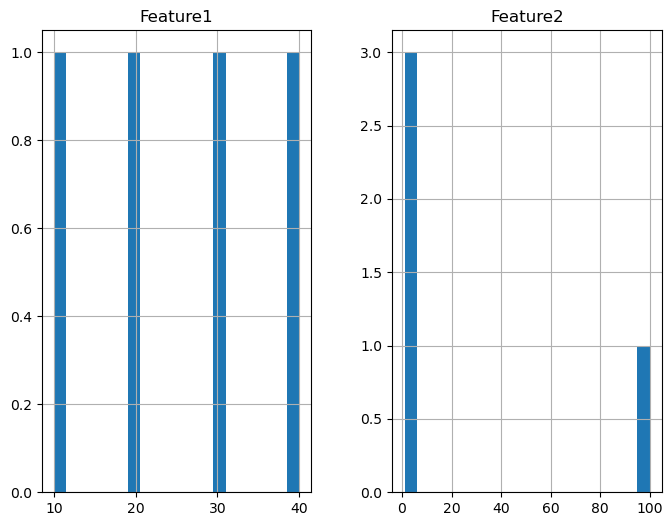

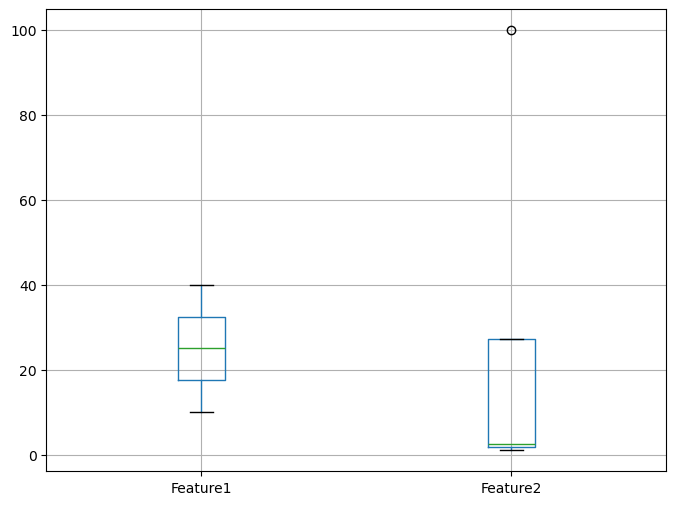

In [24]:
import matplotlib.pyplot as plt

# Plot histograms for each feature
data = pd.DataFrame({
    'Feature1': [10, 20, 30, 40],
    'Feature2': [1, 2, 3, 100],
})
data.hist(bins=20, figsize=(8, 6))
plt.show()

# Boxplot for outliers
data.boxplot(figsize=(8, 6))
plt.show()

## Statistical Summary
You should always look at key metrics such as mean, standard deviation, min, and max values.

In [26]:
print(data.describe())

        Feature1    Feature2
count   4.000000    4.000000
mean   25.000000   26.500000
std    12.909944   49.006802
min    10.000000    1.000000
25%    17.500000    1.750000
50%    25.000000    2.500000
75%    32.500000   27.250000
max    40.000000  100.000000


Common Feature Engineering Operations

Take the log of a variable or raise it to some power
Add/Subtract/Multiple/Divide one variable by one of more other variables
Splitting a value (such as a string) into multiple component parts
Cutting variables into bins

Use a tool like FeatureTools to automate this process if you can
In general, feature engineering is fairly difficult and requires creativity and out of the box thinking, but it can do wonders for your model

Many algorithms require data to be normalized
Here is an example of a training dataset that has been skewed
Applying the PCA technique, results are ambiguous

We’ll get to PCA in a minute, for now see how the data doesn’t offer very well-defined boundaries for our clusters

## Scaling

There are several reasons one might need to standardize data


### StandardScalar

The StandardScaler method from sklearn standardizes features by subtracting the mean and scaling to variance
Subtracting the mean moves the sample mean to zero
Scaling to variance makes the distribution standard normal

In this case we see the same dataset after running through the StandardScaler method
Note we now have much more definable boundaries
Note that if the data is not normally distributed , StandardScaler will not work well

### Min-Max Scalar
If your data is not very Gaussian or the standard deviation is very small you can try the min-max scaler
It essentially shrinks the range of every value between 0 and 1 or -1 and 0

It is sensitive to outliers

### RobustScaler
RobustScaler is similar to MinMax except that it uses the interquartile range instead
This makes it less susceptible to outliers

### Normalizer
Another method is the Normalizer which simply scales each value between 0 and 1
This is accomplished by dividing each value by its magnitude

### One hot encoding
One of the problems with regression algorithms is that you are analyzing numbers and sometimes there are categorical fields in your data
We fix this using one hot encoding
One hot encoding converts categorical data to numeric data by turning each category into an array of values, either 1 or 0 
depending upon whether the value belongs to the particular category

(aka dummycoding, done in pandas)

## Why Data Reduction?
We have already dealt with bad and missing data, but we need to go further
Often analytical data will be very large
Hundreds, even thousands of rows and columns of data

Much of this data will be noise and have little use or worse in our model
We need to get rid of the noise so we can model the good stuff

We have many techniques to apply

### Low Variance Reduction

One simple technique is looking for data that is constant or near constant
Tiny range of values
Little to no diversity

In [ ]:
train_df = pd.read_csv("../Datasets/titanic_train.csv")
train_df.dtypes
train_df.select_dtypes(include = "number").T.apply(lambda x: x.std(), axis=1)
train_df.select_dtypes(exclude = "number").T.apply(lambda x: x.nunique(), axis=1)

High Correlation Variables

### High Correlation Variables

Another approach is to identify variables with a very high correlation
Pierson
Kendall
Spearman

Scatterplots, from a previous exercise might be helpful in identifying then
Remove the variable you believe will be least helpful

### Principal Component Analysis (PCA)
A PCA (Principal Component Analysis) is a statistical technique used to simplify complex data sets. It reduces the dimensionality of data while preserving as much variation as possible, making it easier to interpret and visualize patterns. Here's how it works, tailored for a college-level biologist:

## Why PCA?
Imagine you’re analyzing gene expression data from thousands of genes across multiple samples. This high-dimensional data is difficult to interpret directly. PCA helps by summarizing the data into a few key "principal components" that capture most of the variation.

## How PCA Works:
- Step 1: PCA finds directions (called principal components) in the data where the variation is highest. Think of these as "new axes" for the data.
- Step 2: It reprojects the data onto these new axes, starting with the axis (first principal component) that explains the most variation, then the second, and so on.
- Step 3: You get a new, smaller set of variables that summarize the data effectively.

## Biological Example:
Let’s say you’re comparing 10 samples based on the expression of 1,000 genes. PCA can reduce this to 2–3 components that explain most of the variability in the gene expression. When you plot the samples using these components, you might see clusters corresponding to different conditions (e.g., healthy vs. diseased).

## Why It’s Useful:
- The PCA simplifies complex data for visualization (e.g., scatterplots of principal components).
- Identifies patterns or groups in the data.
- Helps filter out noise, focusing on the most biologically meaningful variation.

In short, PCA is like finding the "essence" of your data by focusing on the most important directions of variation, which is invaluable for high-dimensional datasets like those often found in biology.

Python  can 

In [ ]:
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents
             , columns = ["principal component 1", "principal component 2"])

### Linear Discriminant Analysis (LDA)

Unlike PCA, LDA is supervised
It uses class labels to try to identify attributes that account for the most variance between classes

In [ ]:
target_names = iris.target_names

lda = LinearDiscriminantAnalysis(n_components=2)
lda_r2 = lda.fit(X, y).transform(X)

### Recursive Feature Elimination (RFE)
RFE is a recursive whereby combinations of features are tested to see which features in combination product the best results

In [ ]:
model = LogisticRegression()
# create the RFE model and select 8 attributes
rfe = RFE(model, 8)
rfe = rfe.fit(X, y)

from sklearn.feature_selection import RFECV
# Create the RFE object and compute a cross-validated score.
# The "accuracy" scoring is proportional to the number of correct classifications
rfecv = RFECV(estimator=LogisticRegression(), step=1, cv=10, scoring='accuracy')
rfecv.fit(X, y)

### Singular Value Decomposition (SVD)
SVD is another technique for reducing the number of dimensions before building the model
SVD is an iterative calculation used to decompose a matrix into constituent parts in order to make subsequent calculations easier to manage
It is somewhat similar to PCA, with the end result a matrix with lower rank that approximates the original matrix
One nice thing about SVD is you can get back to your original data if you need to

In [ ]:
U, s, V = linalg.svd( data )

Multidimensional Scaling (MDS)

In cases where the actual values are less important than the distance between values
Here we create a distance matrix
Such a matrix is not affected by rotations or other translations
However, this matrix is not very useful unless we can get back our original data

MDS is able to recover coordinate representations of our data given a distance matrix

Local Linear Embedding (LLE)

While the ISOMAP tries to preserve distances between faraway points, we might instead only be interested in nearby points
This is where Local Linear Embedding comes in
We can then project the local areas onto a reduced space and recombine to preserve the overall geometry
Like ISOMAP, LLE doesn’t handle noisy data well

## Missing Data

One of the biggest headaches in a modeling project is dealing with missing data and obviously bad data
Do you delete it?
Do you ignore it?
Do you replace it?
If so, how?

### Strategies for Missing and Bad Data

Ignore Missing Data
Mark Bad Data as Missing
Remove rows with missing values
Impute missing values
Use algorithms which can handle missing values

#### Mark Bad Data as Missing
We start here because you want to deal with bad data before dealing with missing data
This is pretty easy
Simply set bad values to some arbitrary value
Usually something which won’t affect other data like zero or an empty string
The trick is “knowing” this won’t skew your data in unexpected ways
Better still is to mark bad data as missing

In [ ]:
# mark zero values as missing or NaN
dataset[df_cols] = dataset[df_cols].replace(0, np.NaN)
# count the number of NaN values in each column
print(dataset.isnull().sum())

#### Removing rows with missing values

Another simple technique is to simply remove rows with missing values
Pandas provides the dropna method to accomplish this
Be wary of what’s left
Is it still representative?
Is there enough data left over?

In [ ]:
# mark zero values as missing or NaN
dataset[df_cols] = dataset[df_cols].replace(0, numpy.NaN)
# drop rows with missing values
dataset.dropna(inplace=True)

#### Imputing Values
Another technique for getting rid of missing values is imputation
One method is substitution a summary statistic
Sample mean
Sample median
Sample mode
Last known good value
First known good value
Mean of Last Known/First Known good values

In [ ]:
# mark zero values as missing or NaN
dataset[df_cols] = dataset[df_cols].replace(0, numpy.NaN)
# fill missing values with mean column values
dataset.fillna(dataset.mean(), inplace=True)

Another imputation technique uses something like linear regression to “guess” the imputed value
sklearn supplies the Imputer module for this

In [ ]:
# fill missing values with mean column values
imputer = Imputer()
transformed_X = imputer.fit_transform(X)
# evaluate an LDA model on the dataset using k-fold cross validation
model = LinearDiscriminantAnalysis()
kfold = KFold(n_splits=3, random_state=7)
result = cross_val_score(model, transformed_X, y, cv=kfold, scoring='accuracy')

#### Using an algorithm that accepts missing values

Some algorithms tolerate missing values
One example is a very popular algorithm called xgboost (eXtreme Gradient Boosting) which is a variation on the decision tree
It is relatively fast
It is relatively good
It handles missing values well

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
# fit model on training data
model = XGBClassifier()
model.fit(X_train, y_train)
# make predictions for test data
y_pred = model.predict(X_test)
predictions = [round(value) for value in y_pred]

## Conclusions

After this tutorial, you are now able to do several things.


## Clean up
Remember to shut down your Jupyter Notebook instance when you are done for the day to avoid unnecessary charges. You can do this by stopping the notebook instance from the Cloud console.